In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("student_data.csv")

In [6]:
df.head()

,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


In [7]:
df.isnull().sum()

,0
gender,0
age,0
parental_education_level,0
family_income,4025
daily_study_hours,0
attendance_rate,0
sleep_hours,4113
stress_level,3913
motivation_score,0
private_tutoring,0


In [10]:
df.dropna()

,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Male,18,7,85000.0,7.7,1.000,7.5,7.0,51,True,4,100,97,100,Pass
199996,Female,17,4,65000.0,3.9,0.891,7.2,7.0,55,False,4,46,63,45,Fail
199997,Male,18,4,75000.0,3.2,0.859,7.6,4.0,62,False,4,65,60,58,Pass
199998,Male,21,3,30000.0,4.1,0.950,7.9,5.0,33,False,3,61,77,68,Pass


In [11]:
df.shape

(200000, 15)

In [13]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
X = df.drop("pass_fail", axis=1)
y = df["pass_fail"]

In [15]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2 , random_state = 42)

In [16]:
from sklearn.tree import DecisionTreeClassifier , plot_tree


In [17]:
clf = DecisionTreeClassifier()

In [18]:
clf.fit(X_train , y_train)

DecisionTreeClassifier()

In [19]:
clf.score(X_test , y_test)

0.991675

In [20]:
pred = clf.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

In [22]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18258
           1       0.99      0.99      0.99     21742

    accuracy                           0.99     40000
   macro avg       0.99      0.99      0.99     40000
weighted avg       0.99      0.99      0.99     40000



In [23]:
import matplotlib.pyplot as plt

In [24]:
label = y.map({0 : 'yes' , 1 : 'no'}).unique()

In [25]:
label

array(['yes', 'no'], dtype=object)

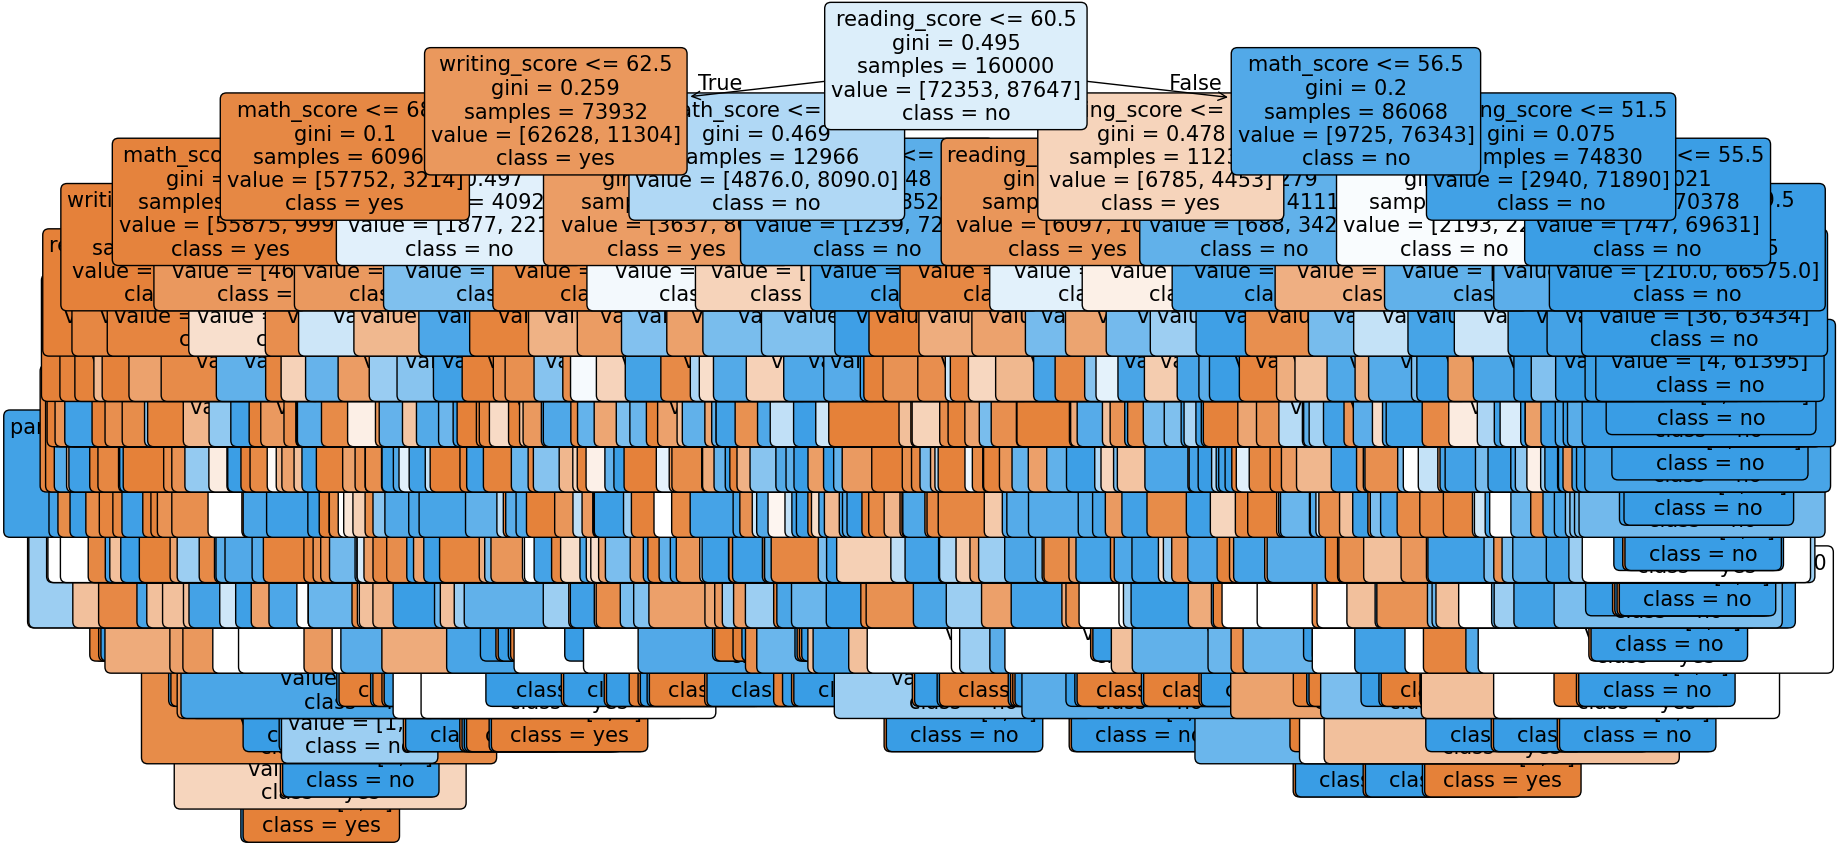

In [27]:
plt.figure(figsize = (20,10))
plot_tree(clf , feature_names= list(X.columns) , class_names=list(label) , rounded=True , filled=True , fontsize=15)
plt.show()